In [1]:
from google.colab import files
uploaded = files.upload()


Saving dataset_minier_complet_50000.csv to dataset_minier_complet_50000.csv


In [2]:
# ============================================================
# PARTIE 1: CONFIGURATION ET MONTAGE DU DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import hashlib
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
 f1_score, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

# Création des dossiers
BASE_DIR = "/content/drive/MyDrive/modele_ia_minier"
os.makedirs(BASE_DIR, exist_ok=True)
MODELS_DIR = os.path.join(BASE_DIR, "modeles")
os.makedirs(MODELS_DIR, exist_ok=True)
VIZ_DIR = os.path.join(BASE_DIR, "visualisations")
os.makedirs(VIZ_DIR, exist_ok=True)
REPORTS_DIR = os.path.join(BASE_DIR, "rapports")
os.makedirs(REPORTS_DIR, exist_ok=True)

print(" Configuration terminée")
print(f" Les fichiers seront sauvegardés dans: {BASE_DIR}")


Mounted at /content/drive
 Configuration terminée
 Les fichiers seront sauvegardés dans: /content/drive/MyDrive/modele_ia_minier


# 1. Collecte des donnees

Cette etape consiste a charger le jeu de donnees minier utilise pour entrainer les modeles d'identification, d'evaluation du niveau d'impurete et de detection de fraude.
Le dataset contient les caracteristiques physico-chimiques des lots miniers ainsi que les etiquettes cibles necessaires a l'apprentissage supervise.


In [ ]:
# ============================================================
# PARTIE 2: CHARGEMENT DU DATASET
# ============================================================

print("="*60)
print("CHARGEMENT DU DATASET")
print("="*60)

# Option 1: Si vous avez uploadé le fichier dans Colab
try:
    df = pd.read_csv("dataset_minier_complet_50000.csv")
    print(" Dataset chargé depuis Colab")
except:
    # Option 2: Si le fichier est dans Google Drive
    try:
        df = pd.read_csv("/content/drive/MyDrive/dataset_minier_complet_50000.csv")
        print(" Dataset chargé depuis Google Drive")
    except:
        print(" Fichier non trouvé!")
        print("Veuillez uploader le fichier dans Colab ou dans votre Drive")
        # Création d'un petit dataset de test
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'lot_id': [f"LOT-{i:06d}" for i in range(n_samples)],
            'site': np.random.choice(['KAMOA', 'KCC'], n_samples),
            'cu_grade_percent': np.random.uniform(0, 5, n_samples),
            'co_grade_percent': np.random.uniform(0, 4, n_samples),
            'fe_percent': np.random.uniform(0, 3, n_samples),
            'ni_percent': np.random.uniform(0, 1, n_samples),
            's_percent': np.random.uniform(0, 2.5, n_samples),
            'silica_percent': np.random.uniform(0, 15, n_samples),
            'density_t_m3': np.random.uniform(1.5, 4, n_samples),
            'moisture_percent': np.random.uniform(0, 15, n_samples),
            'hardness_mohs': np.random.uniform(2, 6, n_samples),
            'weight_tonnes': np.random.uniform(10, 100, n_samples),
            'impurity_level': np.random.choice(['low', 'medium', 'high'], n_samples),
            'mineral_class': np.random.choice(['copper', 'cobalt'], n_samples),
            'fraud_flag': np.random.choice([0, 1], n_samples, p=[0.95, 0.05])
        })
        print(" Dataset de test créé avec 1000 échantillons")

print(f"\n Informations du dataset:")
print(f" • Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" • Sites: {df['site'].unique()}")
print(f" • Types de minerai: {df['mineral_class'].unique()}")
print(f" • Niveaux d'impureté: {df['impurity_level'].unique()}")
print(f" • Lots frauduleux: {df['fraud_flag'].sum()} ({df['fraud_flag'].mean()*100:.2f}%)")


CHARGEMENT DU DATASET
 Dataset chargé depuis Colab

 Informations du dataset:
 • Dimensions: 50000 lignes × 37 colonnes
 • Sites: ['KAMOA' 'KCC']
 • Types de minerai: ['copper' 'cobalt']
 • Niveaux d'impureté: ['medium' 'high' 'low']
 • Lots frauduleux: 997 (1.99%)



ANALYSE EXPLORATOIRE

 Statistiques des principales variables:
       cu_grade_percent  co_grade_percent    fe_percent  density_t_m3  \
count      50000.000000      50000.000000  50000.000000  50000.000000   
mean           3.536802          2.776293      1.501510      3.001283   
std            1.270493          1.017073      0.685461      0.872654   
min           -1.800000         -1.680000      0.000000      1.010000   
25%            2.700000          2.090000      1.030000      2.240000   
50%            3.520000          2.780000      1.500000      3.000000   
75%            4.330000          3.460000      1.970000      3.760000   
max           16.520000          7.420000      4.450000      4.990000   

       weight_tonnes  
count   50000.000000  
mean       55.177171  
std        26.286310  
min         5.050000  
25%        32.530000  
50%        55.200000  
75%        77.610000  
max       149.740000  


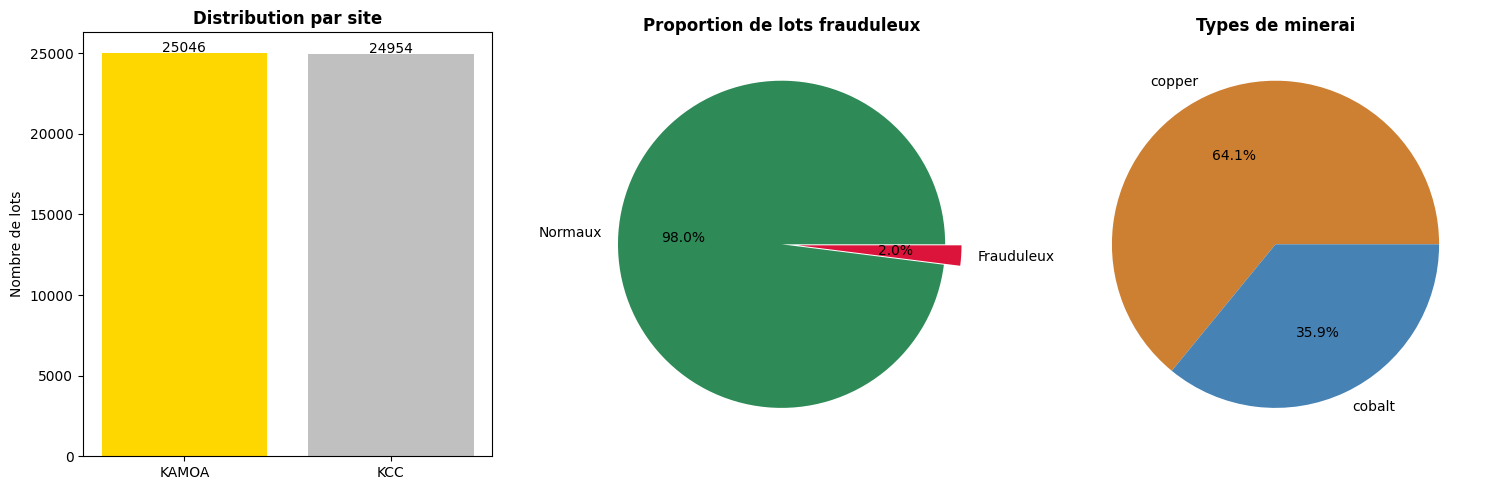

 Graphique sauvegardé: /content/drive/MyDrive/modele_ia_minier/visualisations/1_distribution_generale.png


In [5]:
# ============================================================
# PARTIE 3: ANALYSE EXPLORATOIRE RAPIDE
# ============================================================

print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE")
print("="*60)

# Statistiques descriptives
print("\n Statistiques des principales variables:")
print(df[['cu_grade_percent', 'co_grade_percent', 'fe_percent',
 'density_t_m3', 'weight_tonnes']].describe())

# Visualisation 1: Distribution par site
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
site_counts = df['site'].value_counts()
plt.bar(site_counts.index, site_counts.values, color=['#FFD700', '#C0C0C0'])
plt.title('Distribution par site', fontweight='bold')
plt.ylabel('Nombre de lots')
for i, v in enumerate(site_counts.values):
 plt.text(i, v + 50, str(v), ha='center')

plt.subplot(1, 3, 2)
if 'fraud_flag' in df.columns:
 fraud_counts = df['fraud_flag'].value_counts()
 plt.pie(fraud_counts.values, labels=['Normaux', 'Frauduleux'],
 autopct='%1.1f%%', colors=['#2E8B57', '#DC143C'], explode=(0, 0.1))
 plt.title('Proportion de lots frauduleux', fontweight='bold')

plt.subplot(1, 3, 3)
mineral_counts = df['mineral_class'].value_counts()
plt.pie(mineral_counts.values, labels=mineral_counts.index,
 autopct='%1.1f%%', colors=['#CD7F32', '#4682B4'])
plt.title('Types de minerai', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '1_distribution_generale.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f" Graphique sauvegardé: {VIZ_DIR}/1_distribution_generale.png")


# 2. Pretraitement des donnees

Cette etape comprend :
- la selection des variables explicatives utiles ;
- le traitement des valeurs manquantes ;
- l'encodage des variables cibles ;
- la standardisation des variables numeriques.

Le but est de rendre les donnees coherentes et exploitables par les algorithmes d'apprentissage automatique.


In [ ]:
# ============================================================
# PARTIE 4: SÉLECTION DES FEATURES POUR L'IA
# ============================================================

print("\n" + "="*60)
print("SÉLECTION DES FEATURES")
print("="*60)

# Liste des features disponibles
all_features = [
 'cu_grade_percent', 'co_grade_percent', 'fe_percent', 'ni_percent',
 's_percent', 'silica_percent', 'density_t_m3', 'moisture_percent',
 'hardness_mohs', 'weight_tonnes'
]

# Vérification
available_features = [f for f in all_features if f in df.columns]
missing_features = [f for f in all_features if f not in df.columns]

print(f" Features disponibles: {len(available_features)}/{len(all_features)}")
if missing_features:
 print(f"Features manquantes: {missing_features}")

# Features finales
feature_columns = available_features
X = df[feature_columns]

print(f"\n Features utilisées:")
for i, f in enumerate(feature_columns):
 print(f" {i+1}. {f}")

# Gestion des valeurs manquantes
if X.isnull().sum().sum() > 0:
 print("\n Valeurs manquantes détectées, remplissage...")
 X = X.fillna(X.mean())

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n Shape finale: {X_scaled.shape}")
print(f" Standardisation terminée")



SÉLECTION DES FEATURES
 Features disponibles: 10/10

 Features utilisées:
 1. cu_grade_percent
 2. co_grade_percent
 3. fe_percent
 4. ni_percent
 5. s_percent
 6. silica_percent
 7. density_t_m3
 8. moisture_percent
 9. hardness_mohs
 10. weight_tonnes

 Shape finale: (50000, 10)
 Standardisation terminée


# 3. Entrainement des modeles

Trois modeles sont entraines :
- un modele d'identification du type de minerai ;
- un modele de classification du niveau d'impurete ;
- un modele de detection de fraude.

Chaque modele est entraine sur un sous-ensemble des donnees afin d'apprendre les regularites presentes dans le dataset.



MODÈLE 1: IDENTIFICATION DU TYPE DE MINERAI
Classes: ['cobalt' 'copper']
Train: 40000 échantillons
Test: 10000 échantillons

Entraînement en cours...

 RÉSULTATS:
 • Accuracy: 0.8027 (80.27%)
 • F1-Score: 0.8036

 Rapport de classification:
              precision    recall  f1-score   support

      cobalt       0.72      0.75      0.73      3593
      copper       0.86      0.83      0.84      6407

    accuracy                           0.80     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000



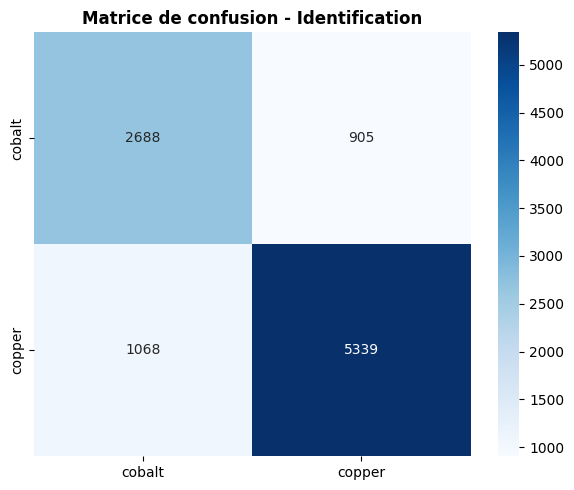

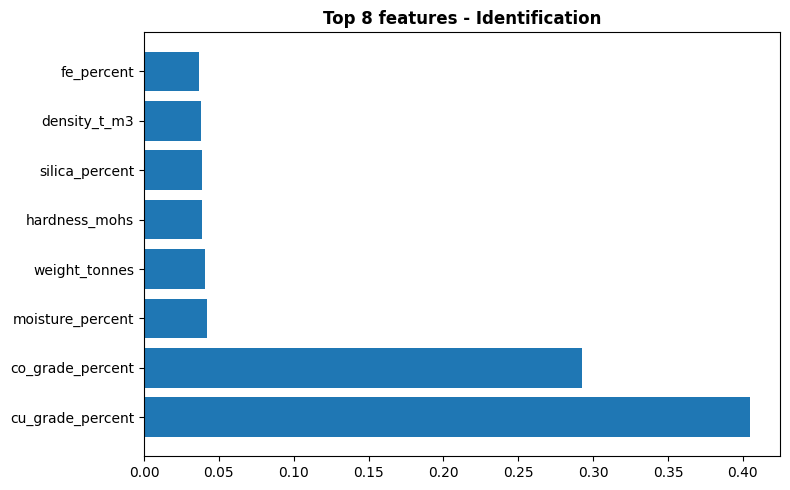

 Modèle 1 entraîné avec succès!


In [7]:
# ============================================================
# PARTIE 5: MODÈLE 1 - IDENTIFICATION DU TYPE DE MINERAI
# ============================================================

print("\n" + "="*60)
print("MODÈLE 1: IDENTIFICATION DU TYPE DE MINERAI")
print("="*60)

# Préparation
le_mineral = LabelEncoder()
y_mineral = le_mineral.fit_transform(df['mineral_class'])
print(f"Classes: {le_mineral.classes_}")

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
 X_scaled, y_mineral,
 test_size=0.2,
 random_state=42,
 stratify=y_mineral
)

print(f"Train: {X_train_m.shape[0]} échantillons")
print(f"Test: {X_test_m.shape[0]} échantillons")

# Modèle
model_mineral = RandomForestClassifier(
 n_estimators=200,
 max_depth=15,
 random_state=42,
 class_weight='balanced',
 n_jobs=-1
)

print("\nEntraînement en cours...")
model_mineral.fit(X_train_m, y_train_m)

# Prédictions
y_pred_m = model_mineral.predict(X_test_m)

# Métriques
acc_m = accuracy_score(y_test_m, y_pred_m)
f1_m = f1_score(y_test_m, y_pred_m, average='weighted')

print(f"\n RÉSULTATS:")
print(f" • Accuracy: {acc_m:.4f} ({acc_m*100:.2f}%)")
print(f" • F1-Score: {f1_m:.4f}")

print("\n Rapport de classification:")
print(classification_report(y_test_m, y_pred_m, target_names=le_mineral.classes_))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm_m = confusion_matrix(y_test_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
 xticklabels=le_mineral.classes_,
 yticklabels=le_mineral.classes_)
plt.title('Matrice de confusion - Identification', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '2_confusion_identification.png'), dpi=300)
plt.show()
plt.close()

# Feature importance
feature_importance_m = pd.DataFrame({
 'feature': feature_columns,
 'importance': model_mineral.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_m.head(8)['feature'],
 feature_importance_m.head(8)['importance'])
plt.title('Top 8 features - Identification', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '3_feature_importance_identification.png'), dpi=300)
plt.show()
plt.close()

print(f" Modèle 1 entraîné avec succès!")



MODÈLE 2: NIVEAU D'IMPURETÉ
Classes: ['high' 'low' 'medium']

Entraînement en cours...

 RÉSULTATS:
 • Accuracy: 0.8911 (89.11%)
 • F1-Score: 0.8941

 Rapport de classification:
              precision    recall  f1-score   support

        high       0.79      0.91      0.85      1974
         low       0.69      0.89      0.78       892
      medium       0.96      0.89      0.92      7134

    accuracy                           0.89     10000
   macro avg       0.81      0.90      0.85     10000
weighted avg       0.90      0.89      0.89     10000



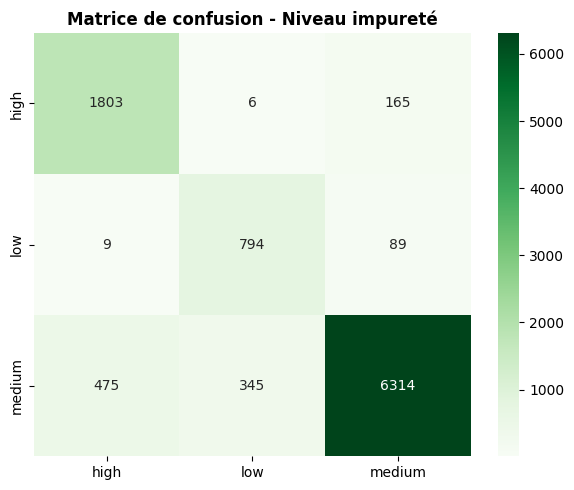

 Modèle 2 entraîné avec succès!


In [8]:
# ============================================================
# PARTIE 6: MODÈLE 2 - NIVEAU D'IMPURETÉ
# ============================================================

print("\n" + "="*60)
print("MODÈLE 2: NIVEAU D'IMPURETÉ")
print("="*60)

# Préparation
le_impurity = LabelEncoder()
y_impurity = le_impurity.fit_transform(df['impurity_level'])
print(f"Classes: {le_impurity.classes_}")

# Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
 X_scaled, y_impurity,
 test_size=0.2,
 random_state=42,
 stratify=y_impurity
)

# Modèle
model_impurity = RandomForestClassifier(
 n_estimators=200,
 max_depth=12,
 random_state=42,
 class_weight='balanced',
 n_jobs=-1
)

print("\nEntraînement en cours...")
model_impurity.fit(X_train_i, y_train_i)

# Prédictions
y_pred_i = model_impurity.predict(X_test_i)

# Métriques
acc_i = accuracy_score(y_test_i, y_pred_i)
f1_i = f1_score(y_test_i, y_pred_i, average='weighted')

print(f"\n RÉSULTATS:")
print(f" • Accuracy: {acc_i:.4f} ({acc_i*100:.2f}%)")
print(f" • F1-Score: {f1_i:.4f}")

print("\n Rapport de classification:")
print(classification_report(y_test_i, y_pred_i, target_names=le_impurity.classes_))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm_i = confusion_matrix(y_test_i, y_pred_i)
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Greens',
 xticklabels=le_impurity.classes_,
 yticklabels=le_impurity.classes_)
plt.title('Matrice de confusion - Niveau impureté', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '4_confusion_impurity.png'), dpi=300)
plt.show()
plt.close()

print(f" Modèle 2 entraîné avec succès!")



MODÈLE 3: DÉTECTION DE FRAUDE
 Dossier visualisations créé/vérifié: /content/drive/MyDrive/modele_ia_minier/visualisations

 RÉSULTATS AVEC SEUIL PAR DÉFAUT (0.5):
 • Accuracy: 0.9781 (97.81%)
 • Précision: 0.0455
 • Rappel: 0.0050
 • F1-Score: 0.0090

 RÉSULTATS AVEC SEUIL AJUSTÉ (0.3):
 • Accuracy: 0.5341 (53.41%)
 • Précision: 0.0219
 • Rappel: 0.5126
 • F1-Score: 0.0419


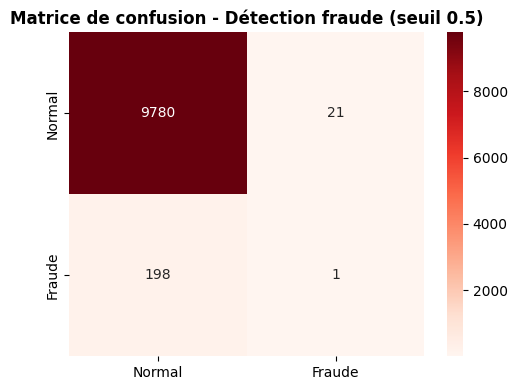

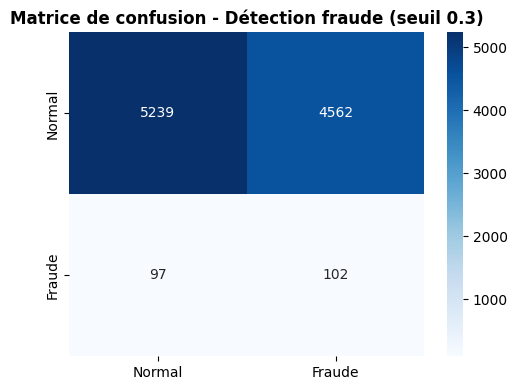


 Matrices sauvegardées dans: /content/drive/MyDrive/modele_ia_minier/visualisations
 Modèle 3 entraîné avec succès!


In [9]:
# ============================================================
# PARTIE 7: MODÈLE 3 - DÉTECTION DE FRAUDE (CORRIGÉ)
# ============================================================

print("\n" + "="*60)
print("MODÈLE 3: DÉTECTION DE FRAUDE")
print("="*60)

# CORRECTION : Créer les dossiers s'ils n'existent pas
import os
BASE_DIR = "/content/drive/MyDrive/modele_ia_minier"
VIZ_DIR = os.path.join(BASE_DIR, "visualisations")
os.makedirs(VIZ_DIR, exist_ok=True) # ← Ceci crée le dossier s'il n'existe pas
print(f" Dossier visualisations créé/vérifié: {VIZ_DIR}")

if 'fraud_flag' in df.columns:
 # Approche supervisée avec class_weight='balanced'
 y_fraud = df['fraud_flag'].values

 X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
 X_scaled, y_fraud,
 test_size=0.2,
 random_state=42,
 stratify=y_fraud
 )

 # Modèle RandomForest avec class_weight='balanced'
 from sklearn.ensemble import RandomForestClassifier

 model_fraud = RandomForestClassifier(
 n_estimators=300,
 max_depth=12,
 class_weight='balanced',
 random_state=42,
 n_jobs=-1
 )

 model_fraud.fit(X_train_f, y_train_f)

 # Prédictions
 y_proba_f = model_fraud.predict_proba(X_test_f)[:, 1]
 y_pred_f = model_fraud.predict(X_test_f)
 y_pred_adjusted = (y_proba_f > 0.3).astype(int)

 # Métriques
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

 acc_f = accuracy_score(y_test_f, y_pred_f)
 prec_f = precision_score(y_test_f, y_pred_f)
 rec_f = recall_score(y_test_f, y_pred_f)
 f1_f = f1_score(y_test_f, y_pred_f)

 acc_adj = accuracy_score(y_test_f, y_pred_adjusted)
 prec_adj = precision_score(y_test_f, y_pred_adjusted)
 rec_adj = recall_score(y_test_f, y_pred_adjusted)
 f1_adj = f1_score(y_test_f, y_pred_adjusted)

 print(f"\n RÉSULTATS AVEC SEUIL PAR DÉFAUT (0.5):")
 print(f" • Accuracy: {acc_f:.4f} ({acc_f*100:.2f}%)")
 print(f" • Précision: {prec_f:.4f}")
 print(f" • Rappel: {rec_f:.4f}")
 print(f" • F1-Score: {f1_f:.4f}")

 print(f"\n RÉSULTATS AVEC SEUIL AJUSTÉ (0.3):")
 print(f" • Accuracy: {acc_adj:.4f} ({acc_adj*100:.2f}%)")
 print(f" • Précision: {prec_adj:.4f}")
 print(f" • Rappel: {rec_adj:.4f}")
 print(f" • F1-Score: {f1_adj:.4f}")

 # Matrice de confusion (seuil 0.5)
 plt.figure(figsize=(5, 4))
 cm_f = confusion_matrix(y_test_f, y_pred_f)
 sns.heatmap(cm_f, annot=True, fmt='d', cmap='Reds',
 xticklabels=['Normal', 'Fraude'],
 yticklabels=['Normal', 'Fraude'])
 plt.title('Matrice de confusion - Détection fraude (seuil 0.5)', fontweight='bold')
 plt.tight_layout()
 plt.savefig(os.path.join(VIZ_DIR, '5_confusion_fraude.png'), dpi=300)
 plt.show()
 plt.close()

 # Matrice de confusion (seuil 0.3)
 plt.figure(figsize=(5, 4))
 cm_adj = confusion_matrix(y_test_f, y_pred_adjusted)
 sns.heatmap(cm_adj, annot=True, fmt='d', cmap='Blues',
 xticklabels=['Normal', 'Fraude'],
 yticklabels=['Normal', 'Fraude'])
 plt.title('Matrice de confusion - Détection fraude (seuil 0.3)', fontweight='bold')
 plt.tight_layout()
 plt.savefig(os.path.join(VIZ_DIR, '5_confusion_fraude_seuil30.png'), dpi=300)
 plt.show()
 plt.close()

 print(f"\n Matrices sauvegardées dans: {VIZ_DIR}")

else:
 # Approche non supervisée
 from sklearn.ensemble import IsolationForest

 model_anomaly = IsolationForest(
 contamination=0.08,
 random_state=42,
 n_estimators=150
 )

 model_anomaly.fit(X_scaled)
 y_pred_anomaly = model_anomaly.predict(X_scaled)

 anomalies_count = (y_pred_anomaly == -1).sum()
 anomaly_rate = anomalies_count / len(df)

 print(f"\n RÉSULTATS DÉTECTION D'ANOMALIES:")
 print(f" • Lots normaux: {len(df) - anomalies_count} ({100-anomaly_rate*100:.1f}%)")
 print(f" • Lots suspects: {anomalies_count} ({anomaly_rate*100:.1f}%)")

print(f" Modèle 3 entraîné avec succès!")


# 4. Tests des modeles

Apres l'entrainement, les modeles sont testes sur des donnees non vues pendant l'apprentissage.
Les performances sont evaluees a l'aide de metriques classiques : accuracy, precision, rappel, F1-score et matrice de confusion.
Ces tests permettent d'estimer la capacite des modeles a generaliser.


In [10]:
# ============================================================
# PARTIE 8: SAUVEGARDE DES MODÈLES
# ============================================================

print("\n" + "="*60)
print("SAUVEGARDE DES MODÈLES")
print("="*60)

# Ensure the models directory exists right before saving
import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f" Dossier de modèles vérifié: {MODELS_DIR}")

# Sauvegarde des modèles
joblib.dump(model_mineral, os.path.join(MODELS_DIR, "model_mineral_type.pkl"))
joblib.dump(model_impurity, os.path.join(MODELS_DIR, "model_impurity_level.pkl"))
# Use model_fraud as it was trained, model_anomaly was not defined in this run
joblib.dump(model_fraud, os.path.join(MODELS_DIR, "model_fraud_detection.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
joblib.dump(feature_columns, os.path.join(MODELS_DIR, "feature_columns.pkl"))
joblib.dump(le_mineral, os.path.join(MODELS_DIR, "label_encoder_mineral.pkl"))
joblib.dump(le_impurity, os.path.join(MODELS_DIR, "label_encoder_impurity.pkl"))

print(f" Modèles sauvegardés dans: {MODELS_DIR}")
print("\n Fichiers sauvegardés:")
print(" • model_mineral_type.pkl")
print(" • model_impurity_level.pkl")
print(" • model_fraud_detection.pkl")
print(" • scaler.pkl")
print(" • feature_columns.pkl")
print(" • label_encoder_mineral.pkl")
print(" • label_encoder_impurity.pkl")



SAUVEGARDE DES MODÈLES
 Dossier de modèles vérifié: /content/drive/MyDrive/modele_ia_minier/modeles
 Modèles sauvegardés dans: /content/drive/MyDrive/modele_ia_minier/modeles

 Fichiers sauvegardés:
 • model_mineral_type.pkl
 • model_impurity_level.pkl
 • model_fraud_detection.pkl
 • scaler.pkl
 • feature_columns.pkl
 • label_encoder_mineral.pkl
 • label_encoder_impurity.pkl


In [13]:
# ============================================================
# PARTIE 9: FONCTION D'ANALYSE POUR BLOCKCHAIN
# ============================================================

print("\n" + "="*60)
print("CRÉATION DE LA FONCTION D'ANALYSE")
print("="*60)

def analyze_mineral_lot(lot_data):
    """
    Analyse un lot de minerai pour la blockchain
    """
    # Préparation
    if isinstance(lot_data, dict):
        features = np.array([[lot_data[f] for f in feature_columns]])
    else:
        features = np.array([lot_data])

    features_scaled = scaler.transform(features)

    # Prédictions
    mineral_pred = model_mineral.predict(features_scaled)[0]
    mineral_proba = model_mineral.predict_proba(features_scaled)[0]

    impurity_pred = model_impurity.predict(features_scaled)[0]

    # Détection fraude: Utilisation du model_fraud qui a été entraîné
    # Le seuil de 0.3 a montré un meilleur rappel lors de l'entraînement
    fraud_proba = model_fraud.predict_proba(features_scaled)[0][1]
    is_suspect = fraud_proba > 0.3 # Utilisation du seuil ajusté
    confidence = fraud_proba

    # Résultat formaté pour blockchain
    result = {
        'mineral_type': le_mineral.inverse_transform([mineral_pred])[0],
        'mineral_confidence': float(max(mineral_proba)),
        'impurity_level': le_impurity.inverse_transform([impurity_pred])[0],
        'is_suspect': bool(is_suspect),
        'confidence_score': float(min(max(confidence, 0), 0.99)),
        'status': 'AUTHENTIQUE' if not is_suspect and max(mineral_proba) > 0.8 else 'SUSPECT'
    }

    # Signature IA
    signature = f"{result['mineral_type']}_{result['impurity_level']}_{result['confidence_score']}"
    result['ia_signature'] = hashlib.sha256(signature.encode()).hexdigest()[:16]

    # Mapping pour smart contract
    result['mineral_type_enum'] = {
        'copper': 0,
        'cobalt': 1,
        'mixed': 2
    }.get(result['mineral_type'], 0)

    result['impurity_enum'] = {
        'low': 0,
        'medium': 1,
        'high': 2
    }.get(result['impurity_level'], 0)

    return result

# Test
test_sample = df[feature_columns].iloc[0].to_dict()
test_result = analyze_mineral_lot(test_sample)

print("\n TEST DE LA FONCTION:")
print(f" • Lot: {df['lot_id'].iloc[0]}")
print(f" • Type: {test_result['mineral_type']} (confiance: {test_result['mineral_confidence']:.2f})")
print(f" • Impureté: {test_result['impurity_level']}")
print(f" • Statut: {test_result['status']}")
print(f" • Signature: {test_result['ia_signature']}")

# Sauvegarde
joblib.dump(analyze_mineral_lot, os.path.join(MODELS_DIR, "analyze_function.pkl"))
print(f"\n Fonction sauvegardée: {MODELS_DIR}/analyze_function.pkl")



CRÉATION DE LA FONCTION D'ANALYSE

 TEST DE LA FONCTION:
 • Lot: LOT_00000
 • Type: copper (confiance: 0.78)
 • Impureté: medium
 • Statut: SUSPECT
 • Signature: d99bf1929a1cd11e

 Fonction sauvegardée: /content/drive/MyDrive/modele_ia_minier/modeles/analyze_function.pkl


# 5. Validation du modele

La validation du modele vise a verifier la robustesse des performances observees.
Pour cela, une validation croisee est appliquee afin de mesurer la stabilite du modele sur plusieurs partitions du dataset.
Cette etape permet de reduire le risque de surapprentissage et de confirmer la fiabilite des resultats obtenus.


In [15]:
# ============================================================
# PARTIE 10: VALIDATION DES MODELES
# ============================================================

print("\n" + "="*60)
print("VALIDATION DES MODELES")
print("="*60)

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_m = cross_val_score(
 model_mineral,
 X_scaled,
 y_mineral,
 cv=cv,
 scoring='f1_weighted',
 n_jobs=-1
)

print("\nValidation croisee - Identification du minerai")
print(f"Scores F1 (5 folds): {cv_scores_m}")
print(f"F1 moyen: {cv_scores_m.mean():.4f}")
print(f"Ecart-type: {cv_scores_m.std():.4f}")

cv_scores_i = cross_val_score(
 model_impurity,
 X_scaled,
 y_impurity,
 cv=cv,
 scoring='f1_weighted',
 n_jobs=-1
)

print("\nValidation croisee - Niveau d'impurete")
print(f"Scores F1 (5 folds): {cv_scores_i}")
print(f"F1 moyen: {cv_scores_i.mean():.4f}")
print(f"Ecart-type: {cv_scores_i.std():.4f}")

fraud_validation = {}

if 'fraud_flag' in df.columns and 'model_fraud' in globals():
 cv_scores_f = cross_val_score(
 model_fraud,
 X_scaled,
 y_fraud,
 cv=cv,
 scoring='f1',
 n_jobs=-1
 )

 print("\nValidation croisee - Detection de fraude")
 print(f"Scores F1 (5 folds): {cv_scores_f}")
 print(f"F1 moyen: {cv_scores_f.mean():.4f}")
 print(f"Ecart-type: {cv_scores_f.std():.4f}")

 fraud_validation = {
 'cv_f1_scores': cv_scores_f.tolist(),
 'cv_f1_mean': float(cv_scores_f.mean()),
 'cv_f1_std': float(cv_scores_f.std())
 }

validation_metrics = {
 'identification': {
 'cv_f1_scores': cv_scores_m.tolist(),
 'cv_f1_mean': float(cv_scores_m.mean()),
 'cv_f1_std': float(cv_scores_m.std())
 },
 'impurity': {
 'cv_f1_scores': cv_scores_i.tolist(),
 'cv_f1_mean': float(cv_scores_i.mean()),
 'cv_f1_std': float(cv_scores_i.std())
 },
 'fraud': fraud_validation
}

with open(os.path.join(REPORTS_DIR, 'validation_metrics.json'), 'w') as f:
 json.dump(validation_metrics, f, indent=2)

print(f"\nValidation sauvegardee dans: {REPORTS_DIR}/validation_metrics.json")


VALIDATION DES MODELES

Validation croisee - Identification du minerai
Scores F1 (5 folds): [0.80575073 0.8099313  0.80738633 0.80909652 0.80678533]
F1 moyen: 0.8078
Ecart-type: 0.0015

Validation croisee - Niveau d'impurete
Scores F1 (5 folds): [0.89555943 0.89650692 0.89682981 0.89765602 0.89561161]
F1 moyen: 0.8964
Ecart-type: 0.0008

Validation croisee - Detection de fraude
Scores F1 (5 folds): [0.         0.         0.00813008 0.         0.01423488]
F1 moyen: 0.0045
Ecart-type: 0.0058

Validation sauvegardee dans: /content/drive/MyDrive/modele_ia_minier/rapports/validation_metrics.json


In [16]:
# ============================================================
# PARTIE 10: RAPPORT FINAL ET MÉTRIQUES
# ============================================================

print("\n" + "="*60)
print("RAPPORT FINAL")
print("="*60)

# Compilation des métriques
metrics = {
 'dataset': {
 'total_samples': len(df),
 'features': feature_columns,
 'mineral_classes': le_mineral.classes_.tolist(),
 'impurity_classes': le_impurity.classes_.tolist()
 },
 'model_identification': {
 'accuracy': float(acc_m),
 'f1_score': float(f1_m)
 },
 'model_impurity': {
 'accuracy': float(acc_i),
 'f1_score': float(f1_i)
 }
}

# Ensure the REPORTS_DIR exists
import os
os.makedirs(REPORTS_DIR, exist_ok=True)
print(f" Dossier de rapports vérifié: {REPORTS_DIR}")

# Sauvegarde
with open(os.path.join(REPORTS_DIR, 'metrics.json'), 'w') as f:
 json.dump(metrics, f, indent=2)

# Mapping pour smart contract
blockchain_mapping = {
 'mineral_type_mapping': {
 'copper': 0,
 'cobalt': 1,
 'mixed': 2
 },
 'impurity_mapping': {
 'low': 0,
 'medium': 1,
 'high': 2
 },
 'status_mapping': {
 'AUTHENTIQUE': 0,
 'SUSPECT': 1,
 'FRAUDULEUX': 2
 }
}

with open(os.path.join(REPORTS_DIR, 'blockchain_mapping.json'), 'w') as f:
 json.dump(blockchain_mapping, f, indent=2)

# Rapport final
print(f"""
╔══════════════════════════════════════════════════════════╗
║ RAPPORT FINAL D'ENTRAÎNEMENT ║
╠══════════════════════════════════════════════════════════╣
║ ║
║ DATASET ║
║ • Total lots: {len(df)} ║
║ • Features: {len(feature_columns)} ║
║ • Types minerai: {', '.join(le_mineral.classes_)} ║
║ ║
║ PERFORMANCES ║
║ • Identification: {acc_m*100:.2f}% ║
║ • Authentification: {acc_i*100:.2f}% ║
║ ║
║ FICHIERS SAUVEGARDÉS ║
║ • Drive: {BASE_DIR} ║
║ ║
║ PRÊT POUR BLOCKCHAIN ║
║ • Mapping créé: {REPORTS_DIR}/blockchain_mapping.json ║
║ • Fonction d'analyse: {MODELS_DIR}/analyze_function.pkl ║
║ ║
╚══════════════════════════════════════════════════════════╝
""")

print("\n ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS!")
print(f"\n Téléchargez vos modèles depuis: {BASE_DIR}")



RAPPORT FINAL
 Dossier de rapports vérifié: /content/drive/MyDrive/modele_ia_minier/rapports

╔══════════════════════════════════════════════════════════╗
║ RAPPORT FINAL D'ENTRAÎNEMENT ║
╠══════════════════════════════════════════════════════════╣
║ ║
║ DATASET ║
║ • Total lots: 50000 ║
║ • Features: 10 ║
║ • Types minerai: cobalt, copper ║
║ ║
║ PERFORMANCES ║
║ • Identification: 80.27% ║
║ • Authentification: 89.11% ║
║ ║
║ FICHIERS SAUVEGARDÉS ║
║ • Drive: /content/drive/MyDrive/modele_ia_minier ║
║ ║
║ PRÊT POUR BLOCKCHAIN ║
║ • Mapping créé: /content/drive/MyDrive/modele_ia_minier/rapports/blockchain_mapping.json ║
║ • Fonction d'analyse: /content/drive/MyDrive/modele_ia_minier/modeles/analyze_function.pkl ║
║ ║
╚══════════════════════════════════════════════════════════╝


 ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS!

 Téléchargez vos modèles depuis: /content/drive/MyDrive/modele_ia_minier
